In [1]:
import numpy as np
import matplotlib.pyplot as plt
import snag
import qse

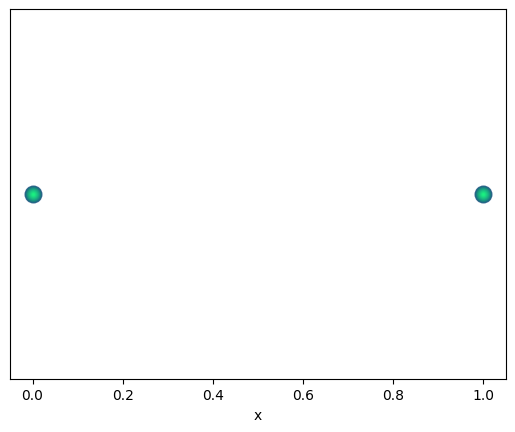

In [2]:
qbits = qse.Qbits(np.array([[0.], [1.]]))
qbits.draw()

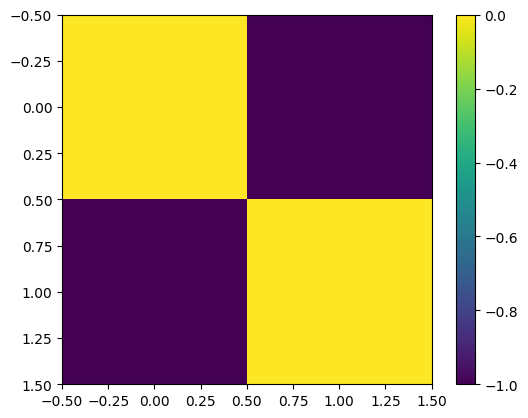

In [3]:
t_mat = - qbits.get_adjacency_matrix(1.)
plt.imshow(t_mat)
plt.colorbar()
plt.show()

In [7]:
calc = snag.Hubbard(n_up=1, n_dn=1, n_sites=qbits.nqbits)
doubles = calc.n_up_n_dn()

print(doubles)
calc.basis

[1 0 0 1]


array([[[1, 0],
        [1, 0]],

       [[1, 0],
        [0, 1]],

       [[0, 1],
        [1, 0]],

       [[0, 1],
        [0, 1]]])

In [8]:
def f(r):
    return np.exp(-r)

In [9]:
separations = np.linspace(1., 2., 2)
for sep in separations:
    qbits.set_distance(0, 1, sep)

    rs = qbits.get_all_distances()
    couplings = - f(rs)
    couplings[0, 0] = couplings[1, 1] = 0.
    print(couplings)

    h_t = calc.hopping(couplings)
    print(h_t)

[[ 0.         -0.36787944]
 [-0.36787944  0.        ]]
[[ 0.         -0.36787944 -0.36787944  0.        ]
 [-0.36787944  0.          0.         -0.36787944]
 [-0.36787944  0.          0.         -0.36787944]
 [ 0.         -0.36787944 -0.36787944  0.        ]]
[[ 0.         -0.13533528]
 [-0.13533528  0.        ]]
[[ 0.         -0.13533528 -0.13533528  0.        ]
 [-0.13533528  0.          0.         -0.13533528]
 [-0.13533528  0.          0.         -0.13533528]
 [ 0.         -0.13533528 -0.13533528  0.        ]]


In [ ]:

data = []

u_vals = np.linspace(0., 20., 10)

for u in u_vals:
    hamiltonian = h_t + u*np.diag(doubles)
    result = np.linalg.eigh(hamiltonian)    
    probs = np.conj(result.eigenvectors[:, 0]) * result.eigenvectors[:, 0]

    assert np.isclose(probs.sum(), 1.)

    d_prob = (probs*doubles).sum()
    data.append(d_prob)

In [ ]:
plt.plot(u_vals, data)
plt.show()